# quantum-solar demo

Residential battery charge/discharge scheduling under time-of-use pricing,
solved as a QUBO with QAOA and verified against exact classical baselines.

The pipeline: `BatteryProblem` → `build_qubo` (exact slack encoding of the SoC
bounds) → `qubo_to_ising` → `QAOASolver`, cross-checked with `brute_force_solve`
(exact, tiny instances) and `dp_solve` (exact, scales to a full day).

In [1]:
import numpy as np

from quantum_solar import (
    synthetic_instance, build_qubo, default_weights,
    brute_force_solve, dp_solve, QAOASolver,
)
from quantum_solar.plotting import plot_schedule

%matplotlib inline

## 1. A small instance

We use a 3-slot instance so the QUBO is small enough to enumerate exactly and to
run on the Aer simulator quickly.

In [2]:
problem = synthetic_instance(num_slots=3, seed=7, capacity=3.0,
                             charge_energy=1.0, initial_soc=1.0)
weights = default_weights(problem)
qubo = build_qubo(problem, weights)

print(f"slots        : {problem.num_slots}")
print(f"QUBO vars    : {qubo.num_vars}  (2T decision bits + slack)")
print(f"prices       : {np.round(problem.price, 3)}")

slots        : 3
QUBO vars    : 10  (2T decision bits + slack)
prices       : [0.109 0.127 0.215]


## 2. Exact baselines

`brute_force_solve` enumerates the QUBO; `dp_solve` optimizes the true problem
with dynamic programming. They must agree on the optimal cost.

In [3]:
brute = brute_force_solve(problem, qubo)
dp = dp_solve(problem)

print(f"brute force : cost ${brute.true_energy:.3f}  feasible={brute.feasible}")
print(f"DP          : cost ${dp.true_energy:.3f}  feasible={dp.feasible}")
assert np.isclose(brute.true_energy, dp.true_energy)

brute force : cost $-0.026  feasible=True
DP          : cost $-0.026  feasible=True


## 3. QAOA on the Aer simulator

QAOA should recover the same optimum the exact solvers found.

In [4]:
result = QAOASolver(reps=3, n_starts=5, shots=4096, seed=1234).solve(problem, qubo)

print(f"QAOA        : cost ${result.true_energy:.3f}  feasible={result.feasible}")
c, d = problem.decode(result.x)
print(f"charge bits : {c}")
print(f"discharge   : {d}")
assert np.isclose(result.true_energy, dp.true_energy)

QAOA        : cost $-0.026  feasible=True
charge bits : [1 0 0]
discharge   : [0 0 1]


## 4. A full-day schedule (synthetic)

The DP solver scales, so we can plan an entire day and visualize the schedule.

daily cost  : $-0.06


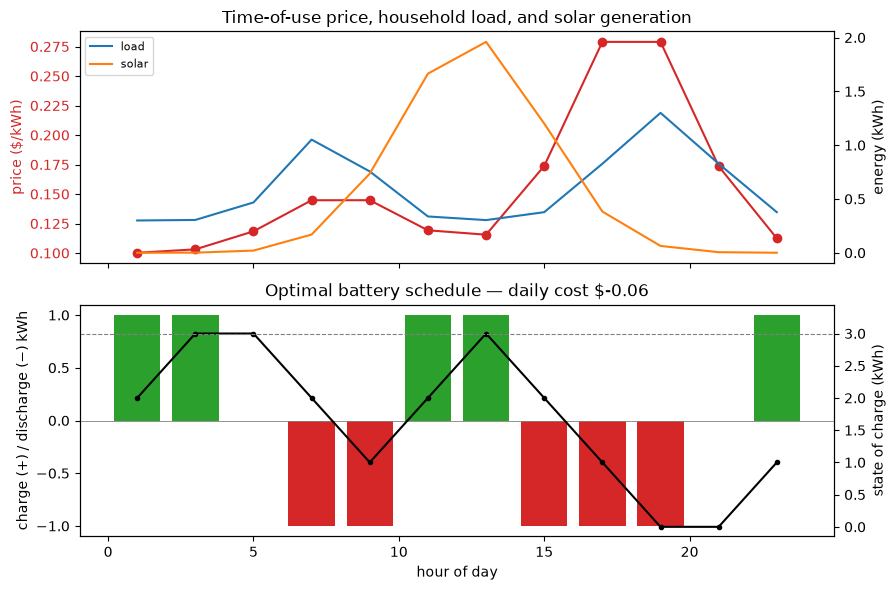

In [5]:
day = synthetic_instance(num_slots=12, seed=1, noise=0.0)
day_solution = dp_solve(day)
print(f"daily cost  : ${day_solution.true_energy:.2f}")

fig = plot_schedule(day, day_solution)

## 5. Real data — NREL PVWatts + Xcel Energy CO RE-TOU

`load_nrel_instance` pulls **real** solar generation (NREL PVWatts) and **real**
time-of-use prices (Xcel Energy Colorado *Residential Energy TOU*, Schedule
RE-TOU, via URDB) for a location; household load stays synthetic. Requires
`NREL_API_KEY` (environment or repo-root `.env`).

daily cost  : $-3.44


Text(0.5, 1.0, 'Real data — NREL PVWatts (Golden, CO) + Xcel Energy CO Residential RE-TOU, summer weekday')

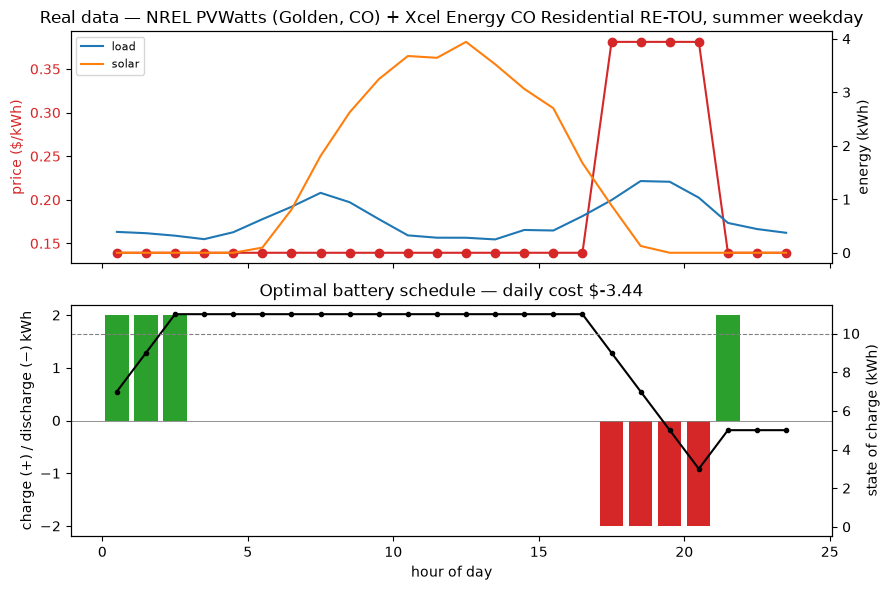

In [6]:
from quantum_solar.data import load_nrel_instance

# Golden, CO (Xcel territory); summer day (day-of-year 172).
real = load_nrel_instance(lat=39.74, lon=-105.18, day=172)
real_solution = dp_solve(real)
print(f"daily cost  : ${real_solution.true_energy:.2f}")

fig = plot_schedule(real, real_solution)
fig.axes[0].set_title(
    "Real data \u2014 NREL PVWatts (Golden, CO) + Xcel Energy CO Residential RE-TOU, summer weekday"
)